# Mental Health Prediction: сравнение моделей

Используем train и val из data/preprocessed, зафиксированные через DVC. 
Сначала один раз обучаем Dummy и выводим его метрики на val без записи в MLflow.
На одном val и на StratifiedKFold сравниваем следующие модели:
- Logistic Regression
- Random Forest
- CatBoost
- LightGBM

MLflow сохраняет параметры, метрики, время работы, версии данных, таблицы и график сравнения. Основная метрика - Accuracy. Дополнительно используются Precision, Recall, F1, ROC-AUC и Average Precision.

## 1. Подготовка данных перед моделью

Читаем готовые train и val из preprocessed. Категории и медианы определяются только по train, затем применяются к val.

- Для LogReg и Random Forest заполняем все числовые пропуски, добавляем индикаторы пропусков и используем get_dummies
- В линейной модели масштабируем числовые признаки
- CatBoost получает строковые категории, LightGBM - pandas category. Обе модели сохраняют структурные NaN

Редкие значения с частотой меньше 5 объединяем в Rare, Пропуски - Missing, неизвестные - Unknown.


In [51]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

PROJECT_DIR = (Path("data_science_project") if Path("data_science_project").is_dir() else Path(".")).resolve()
PREPROCESSED_DIR = PROJECT_DIR / "data/preprocessed"
RANDOM_STATE = 56
TARGET = "Depression"
ACADEMIC_COLUMNS = ["Academic Pressure", "CGPA", "Study Satisfaction"]
WORK_COLUMNS = ["Work Pressure", "Job Satisfaction"]
ROLE_SPECIFIC_COLUMNS = ACADEMIC_COLUMNS + WORK_COLUMNS

In [52]:
from time import perf_counter

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

train_data = pd.read_csv(PREPROCESSED_DIR / "train.csv")
val_data = pd.read_csv(PREPROCESSED_DIR / "val.csv")
X_train = train_data.drop(columns=TARGET)
y_train = train_data[TARGET]
X_val = val_data.drop(columns=TARGET)
y_val = val_data[TARGET]

METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
THRESHOLD = 0.5
N_SPLITS = 5
CV_SEED = 556
THREADS = 4
RARE_MIN_COUNT = 5

### Dummy: начальная оценка

Dummy использует только доли классов в train и не учитывает признаки, поэтому предобработка ему не нужна. Передаем один столбец для задания числа строк

In [22]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train[["id"]], y_train)
dummy_probability = dummy.predict_proba(X_val[["id"]])[:, 1]
dummy_prediction = (dummy_probability >= THRESHOLD).astype(int)

dummy_metrics = {
    "accuracy": accuracy_score(y_val, dummy_prediction),
    "precision": precision_score(y_val, dummy_prediction, zero_division=0),
    "recall": recall_score(y_val, dummy_prediction, zero_division=0),
    "f1": f1_score(y_val, dummy_prediction, zero_division=0),
    "roc_auc": roc_auc_score(y_val, dummy_probability),
    "average_precision": average_precision_score(y_val, dummy_probability),
}
display(pd.DataFrame([dummy_metrics], index=["Dummy"]).round(5))


,accuracy,precision,recall,f1,roc_auc,average_precision
Dummy,0.8183,0.0,0.0,0.0,0.5,0.1817


### DVC и MLflow

Сначала проверка на то, что preprocessed соответствует версии DVC. Если данные изменились после EDA, обновите их командой dvc add data/preprocessed из README.md.

MLflow хранит результаты локально в tracking: параметры и метрики в SQLite, таблицы и график в artifacts. Для val создается отдельный запуск каждой модели. Для CV создается запуск модели с пятью вложенными запусками фолдов, затем сохраняются средние значения и стандартные отклонения. Общий batch_id связывает результаты одного сравнения.

В запуски добавляются SHA-256 файлов train/val, файлы DVC, копию ноутбука и список библиотек. Это позволяет узнать, какие данные и код использовались.

In [54]:
import hashlib
import json
import subprocess
import sys
from uuid import uuid4

import mlflow

status = subprocess.run(
    [sys.executable, "-m", "dvc", "status", "data/preprocessed.dvc", "--json"],
    cwd=PROJECT_DIR, capture_output=True, text=True, check=True,
)
if json.loads(status.stdout):
    raise RuntimeError("Данные preprocessed изменились. Обновите версию DVC по инструкции в README.md.")

TRACKING_DIR = PROJECT_DIR / "tracking"
TRACKING_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{(TRACKING_DIR / 'mlflow.db').as_posix()}")
EXPERIMENT_NAME = "mental-health-models"
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    mlflow.create_experiment(EXPERIMENT_NAME, artifact_location=(TRACKING_DIR / "artifacts").as_uri())
elif experiment.lifecycle_stage == "deleted":
    mlflow.tracking.MlflowClient().restore_experiment(experiment.experiment_id)
mlflow.set_experiment(EXPERIMENT_NAME)
BATCH_ID = uuid4().hex[:12]

DATA_TAGS = {
    "train_sha256": hashlib.sha256((PREPROCESSED_DIR / "train.csv").read_bytes()).hexdigest(),
    "val_sha256": hashlib.sha256((PREPROCESSED_DIR / "val.csv").read_bytes()).hexdigest(),
    "data_source": "data/preprocessed",
}
COMMON_PARAMS = {
    "target": TARGET,
    "threshold": THRESHOLD,
    "split_seed": RANDOM_STATE,
    "val_fraction": 0.20,
    "model_seed": RANDOM_STATE,
    "cv_seed": CV_SEED,
    "n_splits": N_SPLITS,
    "threads": THREADS,
    "rare_min_count": RARE_MIN_COUNT,
}

print(f"Эксперимент: {EXPERIMENT_NAME}, batch_id={BATCH_ID}")


Эксперимент: mental-health-models, batch_id=785a63403ec6


In [55]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

class NotebookPreprocessor(TransformerMixin, BaseEstimator):
    def __init__(self, model_name="CatBoost", rare_min_count=5):
        self.model_name = model_name
        self.rare_min_count = rare_min_count

    def fit(self, X, y=None):
        data = X.drop(columns=["id", "Name"], errors="ignore").copy()
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        self.columns_ = data.columns.tolist()
        self.numeric_ = data.select_dtypes(include="number").columns.tolist()
        self.categorical_ = [column for column in data if column not in self.numeric_]
        self.frequent_ = {}
        self.seen_ = {}
        self.categories_ = {}
        for column in self.categorical_:
            values = data[column].fillna("Missing").astype(str)
            self.seen_[column] = set(values)
            counts = values.value_counts()
            self.frequent_[column] = counts[counts >= self.rare_min_count].index.tolist()
            special = {"Missing", "Unknown", "Rare"}
            cleaned = values.where(values.isin(self.frequent_[column]) | values.isin(special), "Rare")
            self.categories_[column] = sorted(set(cleaned) | special)

        ordinary = [column for column in self.numeric_ if column not in ROLE_SPECIFIC_COLUMNS]
        self.ordinary_medians_ = data[ordinary].median().fillna(0)
        data[ordinary] = data[ordinary].fillna(self.ordinary_medians_)
        self.missing_columns_ = [column for column in self.numeric_ if data[column].isna().any()]
        numeric = self._numeric_data(data)
        self.medians_ = numeric.median().fillna(0)
        self.scaler_ = None
        if self.model_name == "Logistic Regression":
            self.scaler_ = StandardScaler().fit(numeric.fillna(self.medians_))
        self.output_columns_ = self.transform(X).columns.tolist()
        return self

    def _numeric_data(self, data):
        numeric = data[self.numeric_].copy()
        for column in self.missing_columns_:
            numeric[column + " missing"] = data[column].isna().astype(int)
        return numeric

    def transform(self, X):
        check_is_fitted(self, "medians_")
        missing = set(self.columns_) - set(X.columns)
        if missing:
            raise ValueError(f"В данных отсутствуют признаки: {sorted(missing)}")
        data = X[self.columns_].copy()
        ordinary = self.ordinary_medians_.index
        data[ordinary] = data[ordinary].fillna(self.ordinary_medians_)
        for column in self.categorical_:
            values = data[column].fillna("Missing").astype(str)
            special = {"Missing", "Unknown", "Rare"}
            cleaned = values.where(values.isin(self.frequent_[column]) | values.isin(special), "Rare")
            cleaned = cleaned.where(values.isin(self.seen_[column]) | values.isin(special), "Unknown")
            data[column] = cleaned.astype(object)

        if self.model_name in ["Logistic Regression", "Random Forest"]:
            numeric = self._numeric_data(data).fillna(self.medians_).astype(float)
            if self.scaler_ is not None:
                numeric.loc[:, :] = self.scaler_.transform(numeric)
            categorical = data[self.categorical_].copy()
            for column in self.categorical_:
                categorical[column] = pd.Categorical(categorical[column], categories=self.categories_[column])
            encoded = pd.get_dummies(categorical, dtype=float)
            return pd.concat([numeric, encoded], axis=1)

        if self.model_name == "LightGBM":
            for column in self.categorical_:
                data[column] = pd.Categorical(data[column], categories=self.categories_[column])
        return data

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "output_columns_")
        return np.asarray(self.output_columns_, dtype=object)


def prepare_for_model(train_part, val_part, model_name):
    preprocessing = NotebookPreprocessor(model_name, RARE_MIN_COUNT)
    return preprocessing.fit_transform(train_part), preprocessing.transform(val_part)


In [56]:
cat_columns = [column for column in X_train if column != "id" and not pd.api.types.is_numeric_dtype(X_train[column])]

def make_models():
    return {
        "Logistic Regression": LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs"),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, max_depth=18, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=THREADS,
        ),
        "CatBoost": CatBoostClassifier(
            iterations=500, depth=6, learning_rate=0.05, loss_function="Logloss",
            cat_features=cat_columns, random_seed=RANDOM_STATE, thread_count=THREADS,
            verbose=False, allow_writing_files=False,
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=31,
            random_state=RANDOM_STATE, n_jobs=THREADS, verbosity=-1,
            deterministic=True, force_col_wise=True,
        ),
    }


In [57]:
def evaluate_model(model, name, x_fit, y_fit, x_eval, y_eval):
    start = perf_counter()
    x_fit, x_eval = prepare_for_model(x_fit, x_eval, name)
    model.fit(x_fit, y_fit)
    fit_seconds = perf_counter() - start

    start = perf_counter()
    probability = model.predict_proba(x_eval)[:, 1]
    predict_seconds = perf_counter() - start
    prediction = (probability >= THRESHOLD).astype(int)

    return {
        "accuracy": accuracy_score(y_eval, prediction),
        "precision": precision_score(y_eval, prediction, zero_division=0),
        "recall": recall_score(y_eval, prediction, zero_division=0),
        "f1": f1_score(y_eval, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, probability),
        "average_precision": average_precision_score(y_eval, probability),
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
    }

def log_source_artifacts():
    for path in [
        PROJECT_DIR / "data/raw.dvc",
        PROJECT_DIR / "data/preprocessed.dvc",
        PROJECT_DIR / "requirements.txt",
        PROJECT_DIR / "2_models.ipynb",
    ]:
        mlflow.log_artifact(str(path), artifact_path="source")


def log_run_details(name, model, evaluation):
    mlflow.set_tags({"batch_id": BATCH_ID, "model": name, "evaluation": evaluation, **DATA_TAGS})
    mlflow.log_params(COMMON_PARAMS)
    mlflow.log_params({f"model_{key}": str(value) for key, value in model.get_params().items()})
    log_source_artifacts()


## 2. Сравнение на одном val

Параметры заданы выше и одинаковы для val и CV. Подбор параметров и early stopping пока не используется.

Время fit включает подготовку train/val и обучение модели. Время predict показывает вызов predict_proba на готовых признаках.

In [29]:
val_rows = []
for name, model in make_models().items():
    with mlflow.start_run(run_name=f"{name} - val - {BATCH_ID}"):
        log_run_details(name, model, "val")
        mlflow.log_params({"train_rows": len(X_train), "validation_rows": len(X_val)})
        result = evaluate_model(model, name, X_train, y_train, X_val, y_val)
        mlflow.log_metrics(result)

    val_rows.append({"model": name, **result})
    print(f"{name}: Accuracy={result['accuracy']:.5f}, F1={result['f1']:.5f}")

val_results = pd.DataFrame(val_rows).set_index("model").sort_values("accuracy", ascending=False)
display(val_results.round(5))

Logistic Regression: Accuracy=0.94108, F1=0.83509
Random Forest: Accuracy=0.93412, F1=0.81170
CatBoost: Accuracy=0.94101, F1=0.83492
LightGBM: Accuracy=0.94083, F1=0.83556


,accuracy,precision,recall,f1,roc_auc,average_precision,fit_seconds,predict_seconds
model,,,,,,,,
Logistic Regression,0.94108,0.84963,0.82104,0.83509,0.97604,0.90696,5.96650,0.02514
CatBoost,0.94101,0.84928,0.82104,0.83492,0.97675,0.91046,45.31004,0.13043
LightGBM,0.94083,0.84397,0.82730,0.83556,0.97587,0.90703,7.68100,0.71106
Random Forest,0.93412,0.84428,0.78154,0.81170,0.97186,0.89363,15.93324,0.45736


In [30]:
best_val = val_results.index[0]
print(f"На val лидирует {best_val}, Accuracy={val_results.loc[best_val, 'accuracy']:.5f}.")


На val лидирует Logistic Regression, Accuracy=0.94108.


## 3. StratifiedKFold

CV выполняем только на train. Все модели используют одни и те же пять разбиений с seed=556. На каждом фолде создаем новую модель и готовим признаки только по обучающей части.

In [31]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)
folds = list(skf.split(X_train, y_train))
cv_rows = []

for name in make_models():
    model_rows = []
    with mlflow.start_run(run_name=f"{name} - CV - {BATCH_ID}"):
        log_run_details(name, make_models()[name], "cv")
        mlflow.log_param("train_rows", len(X_train))

        for fold, (train_index, val_index) in enumerate(folds, start=1):
            model = make_models()[name]
            with mlflow.start_run(run_name=f"fold {fold}", nested=True):
                mlflow.set_tags({"batch_id": BATCH_ID, "model": name, "evaluation": "cv_fold"})
                mlflow.log_params({"fold": fold, "train_rows": len(train_index), "validation_rows": len(val_index)})
                result = evaluate_model(
                    model, name,
                    X_train.iloc[train_index], y_train.iloc[train_index],
                    X_train.iloc[val_index], y_train.iloc[val_index],
                )
                mlflow.log_metrics(result)

            row = {"model": name, "fold": fold, **result}
            model_rows.append(row)
            cv_rows.append(row)
            print(f"{name}, fold {fold}: Accuracy={result['accuracy']:.5f}, F1={result['f1']:.5f}")

        model_results = pd.DataFrame(model_rows)
        mean = model_results[METRICS + ["fit_seconds", "predict_seconds"]].mean()
        std = model_results[METRICS].std()
        mlflow.log_metrics({f"mean_{metric}": float(value) for metric, value in mean.items()})
        mlflow.log_metrics({f"std_{metric}": float(value) for metric, value in std.items()})
        mlflow.log_table(model_results, artifact_file="tables/folds.json")

cv_results = pd.DataFrame(cv_rows)
cv_mean = cv_results.groupby("model")[METRICS + ["fit_seconds", "predict_seconds"]].mean().sort_values("accuracy", ascending=False)
cv_std = cv_results.groupby("model")[METRICS].std().reindex(cv_mean.index)
print("Средние значения:")
display(cv_mean.round(5))
print("Стандартное отклонение по фолдам:")
display(cv_std.round(5))

Logistic Regression, fold 1: Accuracy=0.93581, F1=0.82114
Logistic Regression, fold 2: Accuracy=0.93967, F1=0.82914
Logistic Regression, fold 3: Accuracy=0.93954, F1=0.82960
Logistic Regression, fold 4: Accuracy=0.93861, F1=0.82755
Logistic Regression, fold 5: Accuracy=0.93745, F1=0.82448
Random Forest, fold 1: Accuracy=0.93257, F1=0.80593
Random Forest, fold 2: Accuracy=0.93403, F1=0.80905
Random Forest, fold 3: Accuracy=0.93381, F1=0.80754
Random Forest, fold 4: Accuracy=0.93190, F1=0.80354
Random Forest, fold 5: Accuracy=0.93163, F1=0.80312
CatBoost, fold 1: Accuracy=0.93648, F1=0.82223
CatBoost, fold 2: Accuracy=0.94012, F1=0.83137
CatBoost, fold 3: Accuracy=0.94158, F1=0.83515
CatBoost, fold 4: Accuracy=0.93905, F1=0.83007
CatBoost, fold 5: Accuracy=0.93799, F1=0.82554
LightGBM, fold 1: Accuracy=0.93536, F1=0.82070
LightGBM, fold 2: Accuracy=0.93847, F1=0.82737
LightGBM, fold 3: Accuracy=0.93985, F1=0.83159
LightGBM, fold 4: Accuracy=0.93812, F1=0.82745
LightGBM, fold 5: Accuracy=

,accuracy,precision,recall,f1,roc_auc,average_precision,fit_seconds,predict_seconds
model,,,,,,,,
CatBoost,0.93904,0.84599,0.81247,0.82887,0.97505,0.90869,39.05841,0.09934
Logistic Regression,0.93822,0.84437,0.80919,0.82638,0.97420,0.90584,5.09376,0.05524
LightGBM,0.93775,0.83916,0.81330,0.82601,0.97357,0.90390,5.67232,0.51411
Random Forest,0.93279,0.84808,0.76763,0.80584,0.97033,0.89219,11.82862,0.38569


Стандартное отклонение по фолдам:


,accuracy,precision,recall,f1,roc_auc,average_precision
model,,,,,,
CatBoost,0.00196,0.00816,0.00474,0.00506,0.00088,0.00354
Logistic Regression,0.00161,0.00871,0.00221,0.00355,0.00085,0.00385
LightGBM,0.00169,0.00732,0.00428,0.00426,0.00071,0.00328
Random Forest,0.00109,0.00612,0.00245,0.00255,0.00063,0.00331


Cреднее показывает качество на пяти разбиениях, стандартное отклонение - его разброс. При близких метриках также учитываем F1 и время обучения.

Лучшую среднюю предсказательную способность показывает CatBoost, однако по времени обучению сильно уступает LogReg

## 4. Val и CV

,val_accuracy,cv_accuracy,cv_accuracy_std,val_f1,cv_f1
model,,,,,
CatBoost,0.94101,0.93904,0.00196,0.83492,0.82887
Logistic Regression,0.94108,0.93822,0.00161,0.83509,0.82638
LightGBM,0.94083,0.93775,0.00169,0.83556,0.82601
Random Forest,0.93412,0.93279,0.00109,0.81170,0.80584


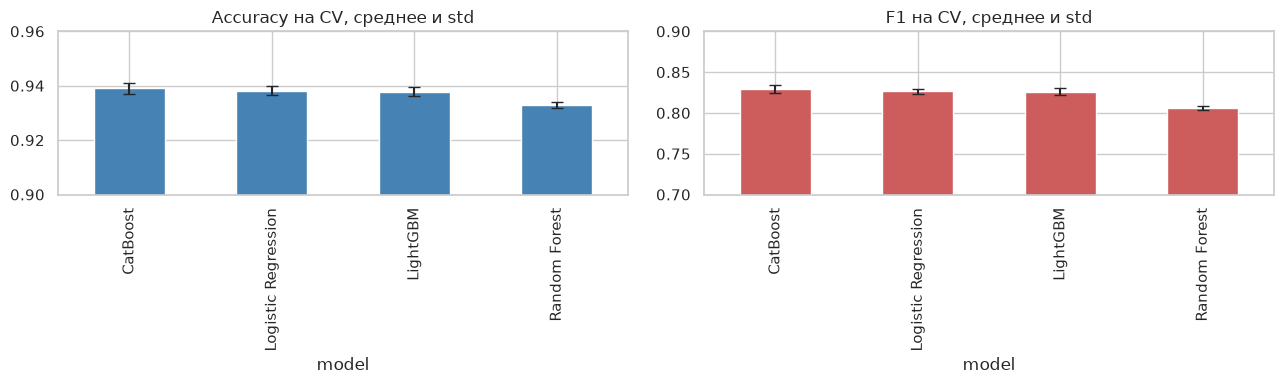

In [35]:
comparison = pd.DataFrame({
    "val_accuracy": val_results["accuracy"],
    "cv_accuracy": cv_mean["accuracy"],
    "cv_accuracy_std": cv_std["accuracy"],
    "val_f1": val_results["f1"],
    "cv_f1": cv_mean["f1"],
}).loc[cv_mean.index]
display(comparison.round(5))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cv_mean["accuracy"].plot.bar(yerr=cv_std["accuracy"], capsize=4, ax=axes[0], color="steelblue")
cv_mean["f1"].plot.bar(yerr=cv_std["f1"], capsize=4, ax=axes[1], color="indianred")
axes[0].set_title("Accuracy на CV, среднее и std")
axes[0].set_ylim(0.9, 0.96)
axes[1].set_title("F1 на CV, среднее и std")
axes[1].set_ylim(0.7, 0.9)
plt.tight_layout()
plt.show()

with mlflow.start_run(run_name=f"Сравнение моделей - {BATCH_ID}"):
    mlflow.set_tags({"batch_id": BATCH_ID, "evaluation": "comparison", **DATA_TAGS})
    mlflow.log_params(COMMON_PARAMS)
    log_source_artifacts()
    mlflow.log_table(val_results.reset_index(), artifact_file="tables/val.json")
    mlflow.log_table(cv_mean.reset_index(), artifact_file="tables/cv_mean.json")
    mlflow.log_table(cv_std.reset_index(), artifact_file="tables/cv_std.json")
    mlflow.log_table(comparison.reset_index(), artifact_file="tables/comparison.json")
    mlflow.log_figure(fig, artifact_file="plots/cv_comparison.png")
    mlflow.set_tag("best_model", cv_mean.index[0])
    mlflow.log_metric("best_cv_accuracy", float(cv_mean.iloc[0]["accuracy"]))

## 5. Выводы

In [37]:
best = cv_mean.index[0]
second = cv_mean.index[1]
gap = cv_mean.loc[best, "accuracy"] - cv_mean.loc[second, "accuracy"]
print(f"Лучший средний Accuracy на CV у {best}: {cv_mean.loc[best, 'accuracy']:.5f}.")
print(f"F1 на CV: {cv_mean.loc[best, 'f1']:.5f}. Accuracy на val: {val_results.loc[best, 'accuracy']:.5f}.")
print(f"Разница со второй моделью ({second}) составляет {gap:.5f} Accuracy.")
print(f"Среднее время подготовки и обучения: {cv_mean.loc[best, 'fit_seconds']:.1f} сек для {best} и {cv_mean.loc[second, 'fit_seconds']:.1f} сек для {second}.")

Лучший средний Accuracy на CV у CatBoost: 0.93904.
F1 на CV: 0.82887. Accuracy на val: 0.94101.
Разница со второй моделью (Logistic Regression) составляет 0.00083 Accuracy.
Среднее время подготовки и обучения: 39.1 сек для CatBoost и 5.1 сек для Logistic Regression.


## 6. Подбор параметров: Logistic Regression и CatBoost

CatBoost немного лучше на CV, Logistic Regression заметно быстрее. Проверяем небольшие сетки, включающие исходные параметры. Остальные параметры оставляем прежними.

- Logistic Regression: C = [0.1, 1, 10]
- CatBoost: depth = [4, 6], learning_rate = [0.03, 0.05]

Используем те же пять фолдов с seed=556. GridSearchCV получает исходные признаки train и Pipeline с преобразователем. Медианы, редкие категории, кодирование и масштабирование определяются отдельно внутри каждого фолда

Основная метрика поиска - Accuracy. Все шесть метрик используют прежний порог 0.5 для текущих настроек.

In [43]:
from importlib.metadata import version

from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline

SEARCH_GRIDS = {
    "Logistic Regression": {"C": [0.1, 1, 10]},
    "CatBoost": {"depth": [4, 6], "learning_rate": [0.03, 0.05]},
}
SEARCH_METRIC = "accuracy"
SEARCH_ID = uuid4().hex[:12]
SEARCH_FOLDS = list(StratifiedKFold(
    n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED,
).split(X_train, y_train))
LIBRARY_VERSIONS = {
    package: version(package)
    for package in ["scikit-learn", "pandas", "numpy", "catboost", "mlflow", "cloudpickle"]
}


def search_metrics(estimator, features, target):
    probability = estimator.predict_proba(features)[:, 1]
    prediction = (probability >= THRESHOLD).astype(int)
    return {
        "accuracy": accuracy_score(target, prediction),
        "precision": precision_score(target, prediction, zero_division=0),
        "recall": recall_score(target, prediction, zero_division=0),
        "f1": f1_score(target, prediction, zero_division=0),
        "roc_auc": roc_auc_score(target, probability),
        "average_precision": average_precision_score(target, probability),
    }


print(f"Grid search: search_id={SEARCH_ID}, batch_id={BATCH_ID}")
for name, grid in SEARCH_GRIDS.items():
    candidates = len(list(ParameterGrid(grid)))
    print(f"{name}: {candidates} кандидатов, {candidates * N_SPLITS} обучений на фолдах и одно на всем train.")


Grid search: search_id=cd42984537fc, batch_id=7e2d9627be27
Logistic Regression: 3 кандидатов, 15 обучений на фолдах и одно на всем train.
CatBoost: 4 кандидатов, 20 обучений на фолдах и одно на всем train.


In [44]:
searches = {}
search_rows = []

for name, grid in SEARCH_GRIDS.items():
    model = make_models()[name]
    if name == "CatBoost":
        model.set_params(cat_features=tuple(cat_columns))
    pipeline = Pipeline([
        ("preprocessing", NotebookPreprocessor(name, RARE_MIN_COUNT)),
        ("model", model),
    ])
    search = GridSearchCV(
        pipeline,
        param_grid={f"model__{key}": values for key, values in grid.items()},
        scoring=search_metrics, refit=SEARCH_METRIC,
        cv=SEARCH_FOLDS, n_jobs=1, error_score="raise", verbose=2,
    )

    with mlflow.start_run(run_name=f"{name} - GridSearch - {SEARCH_ID}") as run:
        mlflow.set_tags({
            "batch_id": BATCH_ID, "search_id": SEARCH_ID,
            "model": name, "evaluation": "grid_search", **DATA_TAGS,
        })
        mlflow.log_params({
            **COMMON_PARAMS, "search_metric": SEARCH_METRIC, "search_n_jobs": 1,
            "candidate_count": len(list(ParameterGrid(grid))),
            "train_rows": len(X_train), "validation_rows": len(X_val),
        })
        mlflow.log_dict(grid, "search/grid.json")
        mlflow.log_dict(model.get_params(), "search/base_model_params.json")
        mlflow.log_dict(LIBRARY_VERSIONS, "source/library_versions.json")
        log_source_artifacts()

        start = perf_counter()
        search.fit(X_train, y_train)
        search_seconds = perf_counter() - start
        best_pipeline = search.best_estimator_
        best_model = best_pipeline.named_steps["model"]
        best_params = {key.removeprefix("model__"): value for key, value in search.best_params_.items()}
        candidates = pd.DataFrame(search.cv_results_)
        candidates["params"] = candidates["params"].map(
            lambda params: json.dumps({key.removeprefix("model__"): value for key, value in params.items()})
        )
        candidates = candidates.sort_values(f"rank_test_{SEARCH_METRIC}")
        mlflow.log_table(candidates, artifact_file="tables/search_candidates.json")
        mlflow.log_text(candidates.to_csv(index=False), "tables/search_candidates.csv")
        mlflow.log_dict(best_params, "search/best_params.json")
        mlflow.log_dict(best_model.get_params(), "search/fitted_model_params.json")
        mlflow.log_params({f"model_{key}": str(value) for key, value in best_model.get_params().items()})
        mlflow.log_params({f"best_{key}": value for key, value in best_params.items()})

        best_folds = pd.DataFrame([
            {
                "fold": fold + 1,
                **{metric: float(search.cv_results_[f"split{fold}_test_{metric}"][search.best_index_]) for metric in METRICS},
            }
            for fold in range(N_SPLITS)
        ])
        best_mean = best_folds[METRICS].mean()
        best_std = best_folds[METRICS].std()
        mlflow.log_table(best_folds, artifact_file="tables/best_cv_folds.json")
        mlflow.log_metrics({f"cv_mean_{key}": float(value) for key, value in best_mean.items()})
        mlflow.log_metrics({f"cv_std_{key}": float(value) for key, value in best_std.items()})
        mean_fit_seconds = float(search.cv_results_["mean_fit_time"][search.best_index_])
        mlflow.log_metrics({
            "search_seconds": search_seconds,
            "refit_seconds": float(search.refit_time_),
            "cv_mean_fit_seconds": mean_fit_seconds,
        })

        start = perf_counter()
        probability = best_pipeline.predict_proba(X_val)[:, 1]
        predict_seconds = perf_counter() - start
        prediction = (probability >= THRESHOLD).astype(int)
        val_metrics = {
            "accuracy": accuracy_score(y_val, prediction),
            "precision": precision_score(y_val, prediction, zero_division=0),
            "recall": recall_score(y_val, prediction, zero_division=0),
            "f1": f1_score(y_val, prediction, zero_division=0),
            "roc_auc": roc_auc_score(y_val, probability),
            "average_precision": average_precision_score(y_val, probability),
        }
        mlflow.log_metrics({f"val_{key}": float(value) for key, value in val_metrics.items()})
        mlflow.log_metric("val_predict_seconds", predict_seconds)
        mlflow.log_table(pd.DataFrame({
            "id": X_val["id"].to_numpy(), "target": y_val.to_numpy(),
            "probability": probability, "prediction": prediction,
        }), artifact_file="tables/val_predictions.json")
        mlflow.sklearn.log_model(
            best_pipeline, name="model", serialization_format="cloudpickle",
            signature=mlflow.models.infer_signature(X_val.head(5), best_pipeline.predict(X_val.head(5))),
            pip_requirements=[f"{package}=={number}" for package, number in LIBRARY_VERSIONS.items()],
        )
        searches[name] = search
        search_rows.append({
            "model": name, "best_params": json.dumps(best_params),
            **{f"cv_{key}": float(value) for key, value in best_mean.items()},
            **{f"cv_{key}_std": float(value) for key, value in best_std.items()},
            **{f"val_{key}": float(value) for key, value in val_metrics.items()},
            "cv_mean_fit_seconds": mean_fit_seconds,
            "search_seconds": search_seconds, "refit_seconds": search.refit_time_,
            "run_id": run.info.run_id,
        })

    print(f"{name}: лучшие параметры {best_params}")
    display(best_folds.round(5))
    print(f"CV Accuracy={best_mean['accuracy']:.5f}, val Accuracy={val_metrics['accuracy']:.5f}, поиск={search_seconds:.1f} сек.")

search_results = pd.DataFrame(search_rows).set_index("model").sort_values("cv_accuracy", ascending=False)
display(search_results.round(5))


Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .......................................model__C=0.1; total time=   6.3s
[CV] END .......................................model__C=0.1; total time=   8.4s
[CV] END .......................................model__C=0.1; total time=   9.5s
[CV] END .......................................model__C=0.1; total time=   6.7s
[CV] END .......................................model__C=0.1; total time=   6.4s
[CV] END .........................................model__C=1; total time=   5.7s
[CV] END .........................................model__C=1; total time=   7.1s
[CV] END .........................................model__C=1; total time=   5.9s
[CV] END .........................................model__C=1; total time=   6.1s
[CV] END .........................................model__C=1; total time=   5.9s
[CV] END ........................................model__C=10; total time=   5.2s
[CV] END ........................................

/media/sf_vm_shared_folder/a_fa/1_module/ds/data_science/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/02 19:17:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization m

Logistic Regression: лучшие параметры {'C': 1}


,fold,accuracy,precision,recall,f1,roc_auc,average_precision
0,1,0.93581,0.83154,0.81100,0.82114,0.97431,0.90485
1,2,0.93967,0.85407,0.80562,0.82914,0.97519,0.90958
2,3,0.93954,0.85014,0.81002,0.82960,0.97374,0.90971
3,4,0.93861,0.84506,0.81076,0.82755,0.97475,0.90446
4,5,0.93745,0.84105,0.80856,0.82448,0.97302,0.90061


CV Accuracy=0.93822, val Accuracy=0.94108, поиск=105.8 сек.
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ..........model__depth=4, model__learning_rate=0.03; total time=  39.1s
[CV] END ..........model__depth=4, model__learning_rate=0.03; total time=  28.8s
[CV] END ..........model__depth=4, model__learning_rate=0.03; total time=  28.1s
[CV] END ..........model__depth=4, model__learning_rate=0.03; total time=  29.0s
[CV] END ..........model__depth=4, model__learning_rate=0.03; total time=  30.5s
[CV] END ..........model__depth=4, model__learning_rate=0.05; total time=  29.7s
[CV] END ..........model__depth=4, model__learning_rate=0.05; total time=  29.5s
[CV] END ..........model__depth=4, model__learning_rate=0.05; total time=  28.3s
[CV] END ..........model__depth=4, model__learning_rate=0.05; total time=  29.7s
[CV] END ..........model__depth=4, model__learning_rate=0.05; total time=  30.1s
[CV] END ..........model__depth=6, model__learning_rate=0.03; total ti

/media/sf_vm_shared_folder/a_fa/1_module/ds/data_science/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/02 19:30:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization m

CatBoost: лучшие параметры {'depth': 6, 'learning_rate': 0.05}


,fold,accuracy,precision,recall,f1,roc_auc,average_precision
0,1,0.93648,0.83637,0.80856,0.82223,0.97498,0.90639
1,2,0.94012,0.85118,0.81247,0.83137,0.97579,0.91201
2,3,0.94158,0.85696,0.81443,0.83515,0.97443,0.91229
3,4,0.93905,0.84111,0.81932,0.83007,0.97605,0.90864
4,5,0.93799,0.84433,0.80758,0.82554,0.97398,0.90412


CV Accuracy=0.93904, val Accuracy=0.94101, поиск=774.0 сек.


,best_params,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,cv_average_precision,cv_accuracy_std,cv_precision_std,cv_recall_std,cv_f1_std,cv_roc_auc_std,cv_average_precision_std,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_average_precision,cv_mean_fit_seconds,search_seconds,refit_seconds,run_id
model,,,,,,,,,,,,,,,,,,,,,,,
CatBoost,"{""depth"": 6, ""learning_rate"": 0.05}",0.93904,0.84599,0.81247,0.82887,0.97505,0.90869,0.00196,0.00816,0.00474,0.00506,0.00088,0.00354,0.94101,0.84928,0.82104,0.83492,0.97675,0.91046,43.63228,773.95216,47.02805,d90097ff617849c6b723f78dd30e4db8
Logistic Regression,"{""C"": 1}",0.93822,0.84437,0.80919,0.82638,0.97420,0.90584,0.00161,0.00871,0.00221,0.00355,0.00085,0.00385,0.94108,0.84963,0.82104,0.83509,0.97604,0.90696,5.78149,105.79018,6.88530,337d5228da7840bb8fed881b06a25ca6


## 7. Сравнение до и после подбора


,baseline_cv_accuracy,tuned_cv_accuracy,tuned_cv_std,baseline_val_accuracy,tuned_val_accuracy,baseline_val_f1,tuned_val_f1,baseline_fit_seconds,tuned_fit_seconds,search_seconds,cv_accuracy_gain
model,,,,,,,,,,,
CatBoost,0.93904,0.93904,0.00196,0.94101,0.94101,0.83492,0.83492,39.05841,43.63228,773.95216,-0.0
Logistic Regression,0.93822,0.93822,0.00161,0.94108,0.94108,0.83509,0.83509,5.09376,5.78149,105.79018,0.0


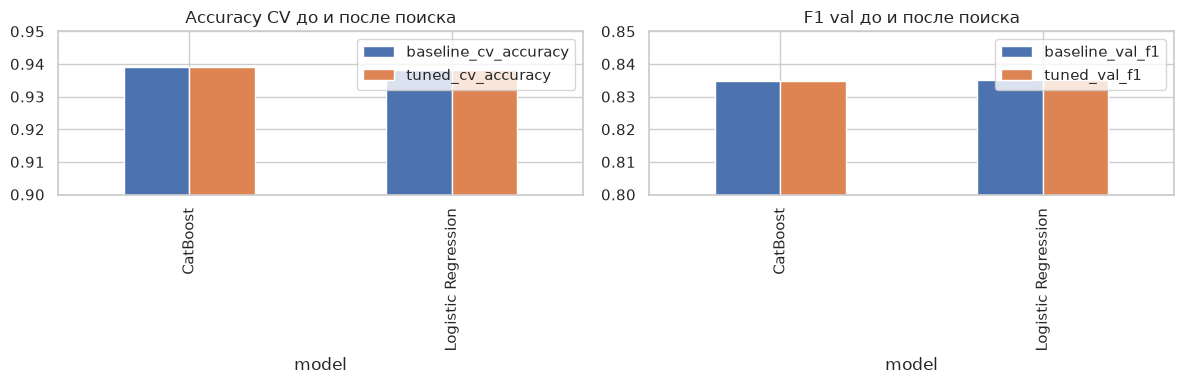

Лучший Accuracy CV после поиска: CatBoost, 0.9390431.


In [50]:
tuning_comparison = pd.DataFrame({
    "baseline_cv_accuracy": cv_mean.loc[search_results.index, "accuracy"],
    "tuned_cv_accuracy": search_results["cv_accuracy"],
    "tuned_cv_std": search_results["cv_accuracy_std"],
    "baseline_val_accuracy": val_results.loc[search_results.index, "accuracy"],
    "tuned_val_accuracy": search_results["val_accuracy"],
    "baseline_val_f1": val_results.loc[search_results.index, "f1"],
    "tuned_val_f1": search_results["val_f1"],
    "baseline_fit_seconds": cv_mean.loc[search_results.index, "fit_seconds"],
    "tuned_fit_seconds": search_results["cv_mean_fit_seconds"],
    "search_seconds": search_results["search_seconds"],
})
tuning_comparison["cv_accuracy_gain"] = tuning_comparison["tuned_cv_accuracy"] - tuning_comparison["baseline_cv_accuracy"]
display(tuning_comparison.round(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tuning_comparison[["baseline_cv_accuracy", "tuned_cv_accuracy"]].plot.bar(ax=axes[0])
tuning_comparison[["baseline_val_f1", "tuned_val_f1"]].plot.bar(ax=axes[1])
axes[0].set_title("Accuracy CV до и после поиска")
axes[1].set_title("F1 val до и после поиска")
axes[0].set_ylim(0.9, 0.95)
axes[1].set_ylim(0.8, 0.85)
plt.tight_layout()
plt.show()

with mlflow.start_run(run_name=f"Сравнение GridSearch - {SEARCH_ID}"):
    mlflow.set_tags({"batch_id": BATCH_ID, "search_id": SEARCH_ID, "evaluation": "grid_search_comparison", **DATA_TAGS})
    mlflow.log_params(COMMON_PARAMS)
    mlflow.log_table(search_results.reset_index(), artifact_file="tables/tuned_models.json")
    mlflow.log_table(tuning_comparison.reset_index(), artifact_file="tables/baseline_vs_tuned.json")
    mlflow.log_figure(fig, artifact_file="plots/baseline_vs_tuned.png")
    log_source_artifacts()

best_tuned = search_results.index[0]
print(f"Лучший Accuracy CV после поиска: {best_tuned}, {search_results.loc[best_tuned, 'cv_accuracy']:.7f}.")


## 8. Важность признаков и матрица ошибок

Используем лучшие Pipeline из GridSearch, обученные только на train. На val строим матрицы ошибок в абсолютных числах и долях внутри истинного класса. Порог = 0.5.

Для LogReg показываем модуль коэффициента с именами признаков после кодирования. Числовые признаки масштабированы, категории представлены отдельными индикаторами. Знак коэффициента сохраняем в таблице: положительный повышает оценку класса 1, отрицательный снижает. Модуль коэффициента не равен важности исходного признака целиком, поскольку один категориальный признак становится несколькими столбцами.

Для CatBoost используем PredictionValuesChange - встроенную важность по изменениям предсказаний. Шкалы двух методов различаются, их численные значения между моделями не сравниваем.


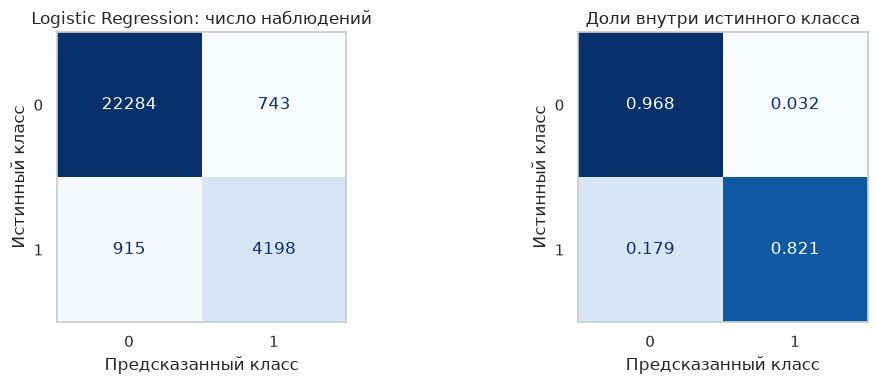

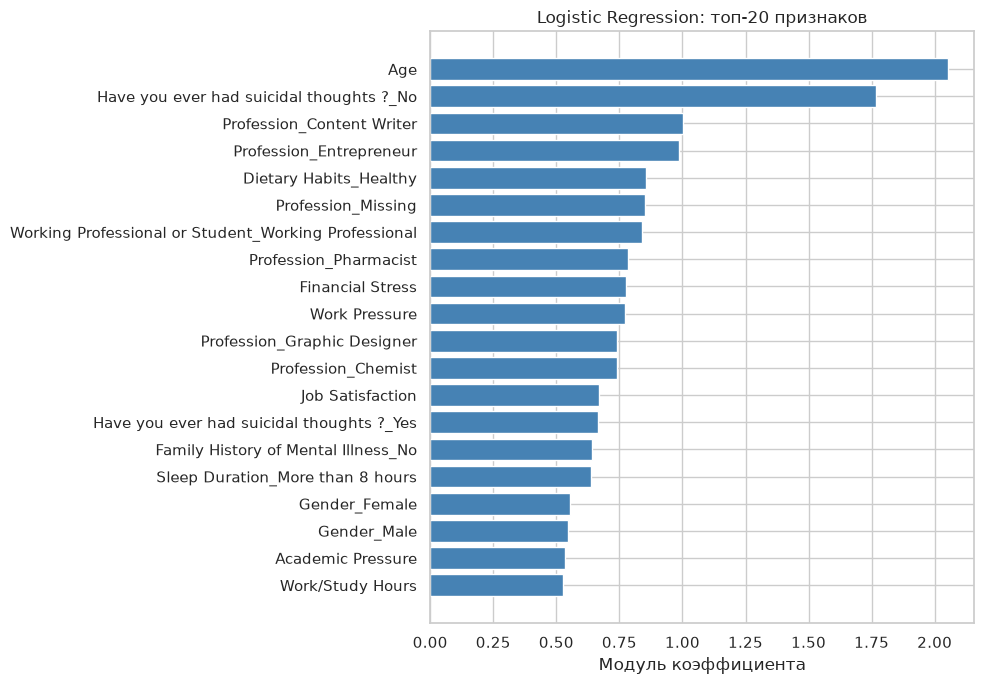

,feature,importance,coefficient
0,Age,2.05320,-2.05320
1,Have you ever had suicidal thoughts ?_No,1.76651,-1.76651
2,Profession_Content Writer,1.00043,-1.00043
3,Profession_Entrepreneur,0.98758,-0.98758
4,Dietary Habits_Healthy,0.85419,-0.85419
5,Profession_Missing,0.85216,0.85216
6,Working Professional or Student_Working Profes...,0.83793,-0.83793
7,Profession_Pharmacist,0.78607,-0.78607
8,Financial Stress,0.77601,0.77601
9,Work Pressure,0.77382,0.77382


Logistic Regression: пропущено положительных случаев 915, ложных срабатываний 743.


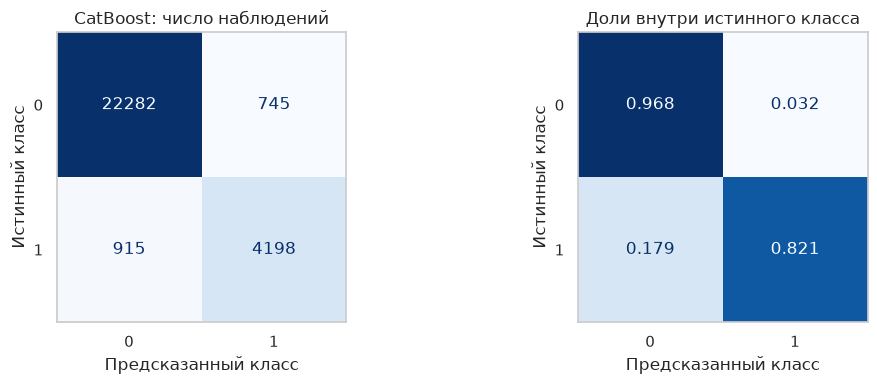

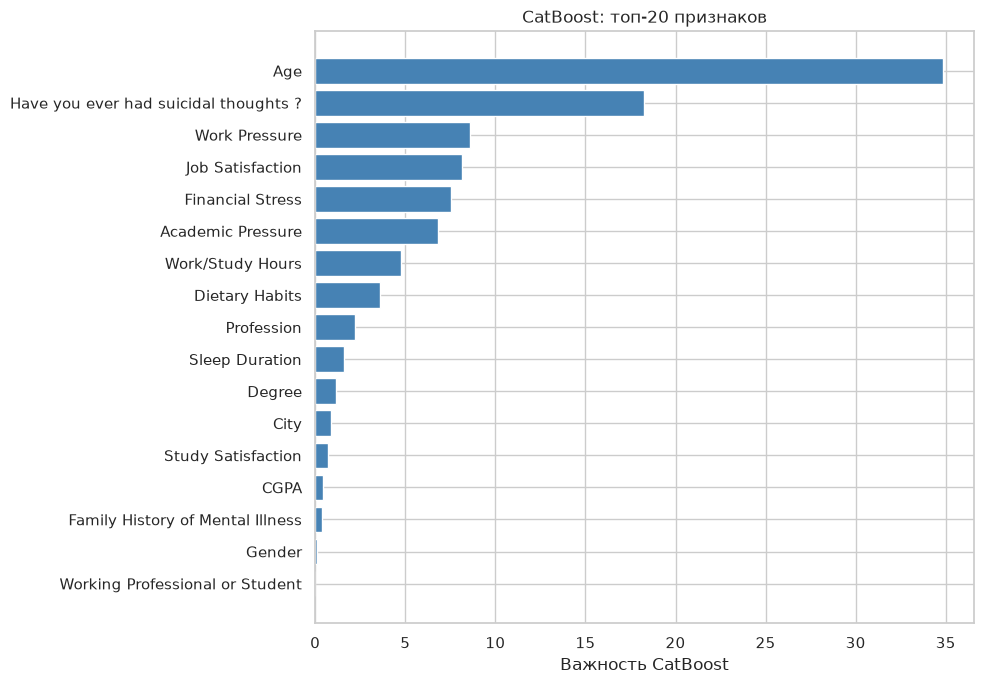

,feature,importance
0,Age,34.82681
1,Have you ever had suicidal thoughts ?,18.25568
2,Work Pressure,8.57140
3,Job Satisfaction,8.17386
4,Financial Stress,7.55817
5,Academic Pressure,6.81401
6,Work/Study Hours,4.77533
7,Dietary Habits,3.58615
8,Profession,2.19316
9,Sleep Duration,1.58860


CatBoost: пропущено положительных случаев 915, ложных срабатываний 745.


,FP,FN,accuracy,precision,recall,f1,roc_auc,average_precision
model,,,,,,,,
Logistic Regression,743,915,0.94108,0.84963,0.82104,0.83509,0.97604,0.90696
CatBoost,745,915,0.94101,0.84928,0.82104,0.83492,0.97675,0.91046


In [63]:
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

SELECTED_MODELS = ["Logistic Regression", "CatBoost"]
MODEL_FILES = {"Logistic Regression": "logreg", "CatBoost": "catboost"}
REPORTS_DIR = PROJECT_DIR / "artifacts/reports" / f"notebook_{SEARCH_ID}"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TOP_FEATURES = 20
analysis_rows = []
analysis_run_ids = {}

for name in SELECTED_MODELS:
    fitted_pipeline = searches[name].best_estimator_
    fitted_model = fitted_pipeline.named_steps["model"]
    preprocessing = fitted_pipeline.named_steps["preprocessing"]
    probability = fitted_pipeline.predict_proba(X_val)[:, 1]
    prediction = (probability >= THRESHOLD).astype(int)
    matrix = confusion_matrix(y_val, prediction, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    metrics = search_metrics(fitted_pipeline, X_val, y_val)

    feature_names = preprocessing.get_feature_names_out()
    if name == "Logistic Regression":
        coefficients = fitted_model.coef_[0]
        importance = pd.DataFrame({
            "feature": feature_names,
            "importance": np.abs(coefficients),
            "coefficient": coefficients,
        })
        importance_title = "Модуль коэффициента"
    else:
        importance = pd.DataFrame({
            "feature": feature_names,
            "importance": fitted_model.get_feature_importance(type="PredictionValuesChange"),
        })
        importance_title = "Важность CatBoost"
    importance = importance.sort_values("importance", ascending=False).reset_index(drop=True)

    fig_matrix, axes = plt.subplots(1, 2, figsize=(11, 4))
    ConfusionMatrixDisplay(matrix, display_labels=[0, 1]).plot(
        ax=axes[0], cmap="Blues", colorbar=False, values_format="d",
    )
    normalized = matrix / matrix.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(normalized, display_labels=[0, 1]).plot(
        ax=axes[1], cmap="Blues", colorbar=False, values_format=".3f",
    )
    axes[0].set_title(f"{name}: число наблюдений")
    axes[1].set_title("Доли внутри истинного класса")
    for ax in axes:
        ax.set_xlabel("Предсказанный класс")
        ax.set_ylabel("Истинный класс")
        ax.grid(False)
    fig_matrix.tight_layout()
    
    plt.show()

    fig_importance, ax = plt.subplots(figsize=(10, 7))
    top = importance.head(TOP_FEATURES).sort_values("importance")
    ax.barh(top["feature"], top["importance"], color="steelblue")
    ax.set_title(f"{name}: топ-{TOP_FEATURES} признаков")
    ax.set_xlabel(importance_title)
    fig_importance.tight_layout()
    plt.grid(True)
    plt.show()
    display(importance.head(TOP_FEATURES).round(5))

    errors = X_val.copy()
    errors["target"] = y_val.to_numpy()
    errors["probability"] = probability
    errors["prediction"] = prediction
    errors = errors.loc[errors["target"] != errors["prediction"]].copy()
    errors["error_type"] = np.where(errors["target"] == 1, "FN", "FP")
    prefix = MODEL_FILES[name]
    importance_path = REPORTS_DIR / f"{prefix}_feature_importance.csv"
    errors_path = REPORTS_DIR / f"{prefix}_val_errors.csv"
    matrix_path = REPORTS_DIR / f"{prefix}_confusion_matrix.png"
    figure_path = REPORTS_DIR / f"{prefix}_feature_importance.png"
    importance.to_csv(importance_path, index=False)
    errors.to_csv(errors_path, index=False)
    fig_matrix.savefig(matrix_path, dpi=150, bbox_inches="tight")
    fig_importance.savefig(figure_path, dpi=150, bbox_inches="tight")

    with mlflow.start_run(run_name=f"{name} - Анализ val - {SEARCH_ID}") as run:
        log_run_details(name, fitted_model, "best_model_analysis")
        mlflow.set_tags({
            "search_id": SEARCH_ID,
            "source_search_run_id": search_results.loc[name, "run_id"],
            "fit_data": "train", "evaluation_data": "val",
        })
        mlflow.log_params({"importance_type": "abs_coefficient" if name == "Logistic Regression" else "PredictionValuesChange", "top_features": TOP_FEATURES})
        mlflow.log_metrics({f"val_{key}": float(value) for key, value in metrics.items()})
        mlflow.log_metrics({"true_negative": int(tn), "false_positive": int(fp), "false_negative": int(fn), "true_positive": int(tp)})
        mlflow.log_dict({"labels": [0, 1], "counts": matrix.tolist(), "normalized": normalized.tolist()}, "tables/confusion_matrix.json")
        mlflow.log_artifact(str(importance_path), artifact_path="tables")
        mlflow.log_artifact(str(errors_path), artifact_path="tables")
        mlflow.log_artifact(str(matrix_path), artifact_path="plots")
        mlflow.log_artifact(str(figure_path), artifact_path="plots")
        analysis_run_ids[name] = run.info.run_id

    plt.close(fig_matrix)
    plt.close(fig_importance)
    analysis_rows.append({"model": name, "FP": int(fp), "FN": int(fn), **metrics})
    print(f"{name}: пропущено положительных случаев {fn}, ложных срабатываний {fp}.")

analysis_results = pd.DataFrame(analysis_rows).set_index("model")
display(analysis_results.round(5))


## 9. Финальное предсказания для Kaggle

После анализа фиксируем выбранные по CV параметры. Создаем новые копии лучших Pipeline и заново обучаем их на объединенных train + val. Все преобразования также обучаются заново на этой выборке. Модели для анализа val остаются прежними. Метрики раздела 8 относятся к моделям на train, а не к финальным моделям на train + val.

Читаем data/preprocessed/test.csv - Kaggle test после той же фиксированной очистки, что и train/val.

В Kaggle test нет меток, поэтому метрики качества проверяются на Kaggle

In [67]:
kaggle_test = pd.read_csv(PREPROCESSED_DIR / "test.csv")
raw_test_ids = pd.read_csv(PROJECT_DIR / "data/raw/test.csv", usecols=["id"])["id"]
if not kaggle_test["id"].equals(raw_test_ids):
    raise ValueError("Состав или порядок Kaggle test изменился после подготовки.")
if kaggle_test["id"].duplicated().any():
    raise ValueError("В Kaggle test обнаружены повторяющиеся id.")
if set(kaggle_test.columns) != set(X_train.columns):
    raise ValueError("Признаки Kaggle test отличаются от train.")
kaggle_test = kaggle_test[X_train.columns]

full_train = pd.concat([train_data, val_data], ignore_index=True)
X_full = full_train.drop(columns=TARGET)
y_full = full_train[TARGET]
SUBMISSIONS_DIR = PROJECT_DIR / "artifacts/submissions" / SEARCH_ID
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_ID = uuid4().hex[:12]
TEST_TAGS = {
    "kaggle_test_sha256": hashlib.sha256((PREPROCESSED_DIR / "test.csv").read_bytes()).hexdigest(),
    "full_train_sha256": hashlib.sha256(full_train.to_csv(index=False).encode()).hexdigest(),
}
print(f"Финальное обучение: {len(X_full)} строк, Kaggle test: {len(kaggle_test)} строк.")


Финальное обучение: 140695 строк, Kaggle test: 93800 строк.


In [69]:
final_models = {}
submission_rows = []

for name in SELECTED_MODELS:
    final_pipeline = clone(searches[name].best_estimator_)
    with mlflow.start_run(run_name=f"{name} - Kaggle predict - {FINAL_ID}") as run:
        log_run_details(name, final_pipeline.named_steps["model"], "kaggle_prediction")
        mlflow.set_tags({
            "search_id": SEARCH_ID, "final_id": FINAL_ID,
            "source_search_run_id": search_results.loc[name, "run_id"],
            "source_analysis_run_id": analysis_run_ids[name],
            "fit_data": "train+val", "prediction_data": "data/preprocessed/test.csv",
            **TEST_TAGS,
        })
        mlflow.log_params({
            "full_train_rows": len(X_full), "test_rows": len(kaggle_test),
            "full_train_positive_fraction": float(y_full.mean()),
        })
        mlflow.log_dict(LIBRARY_VERSIONS, "source/library_versions.json")
        mlflow.log_dict(
            {key.removeprefix("model__"): value for key, value in searches[name].best_params_.items()},
            "search/best_params.json",
        )

        start = perf_counter()
        final_pipeline.fit(X_full, y_full)
        fit_seconds = perf_counter() - start
        start = perf_counter()
        probability = final_pipeline.predict_proba(kaggle_test)[:, 1]
        predict_seconds = perf_counter() - start
        if not np.isfinite(probability).all():
            raise ValueError("В предсказаниях появились пропуски или бесконечные значения.")
        prediction = (probability >= THRESHOLD).astype(int)

        submission = pd.DataFrame({"id": kaggle_test["id"].to_numpy(), TARGET: prediction})
        prefix = MODEL_FILES[name]
        submission_path = SUBMISSIONS_DIR / f"submission_{prefix}.csv"
        submission.to_csv(submission_path, index=False)

        mlflow.log_metrics({
            "fit_seconds": fit_seconds, "predict_seconds": predict_seconds,
            "predicted_positive_fraction": float(prediction.mean()),
        })
        mlflow.log_artifact(str(submission_path), artifact_path="submissions")
        mlflow.sklearn.log_model(
            final_pipeline, name="model", serialization_format="cloudpickle",
            signature=mlflow.models.infer_signature(kaggle_test.head(5), final_pipeline.predict(kaggle_test.head(5))),
            pip_requirements=[f"{package}=={number}" for package, number in LIBRARY_VERSIONS.items()],
        )
        final_models[name] = final_pipeline
        submission_rows.append({
            "model": name, "rows": len(submission),
            "positive_fraction": float(prediction.mean()),
            "fit_seconds": fit_seconds, "predict_seconds": predict_seconds,
            "submission": str(submission_path), "run_id": run.info.run_id,
        })

    print(f"{name}: сохранен {submission_path}")

submission_results = pd.DataFrame(submission_rows).set_index("model")
display(submission_results)


/media/sf_vm_shared_folder/a_fa/1_module/ds/data_science/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/02 20:52:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization m

Logistic Regression: сохранен /media/sf_vm_shared_folder/a_fa/1_module/ds/data_science/data_science_project/artifacts/submissions/cd42984537fc/submission_logreg.csv


/media/sf_vm_shared_folder/a_fa/1_module/ds/data_science/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/02 20:53:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization m

CatBoost: сохранен /media/sf_vm_shared_folder/a_fa/1_module/ds/data_science/data_science_project/artifacts/submissions/cd42984537fc/submission_catboost.csv


,rows,positive_fraction,fit_seconds,predict_seconds,submission,run_id
model,,,,,,
Logistic Regression,93800,0.174435,21.042052,2.274956,/media/sf_vm_shared_folder/a_fa/1_module/ds/da...,6f8d7d5d30a5462d8eaf054dbfdd016a
CatBoost,93800,0.175213,76.519053,0.855014,/media/sf_vm_shared_folder/a_fa/1_module/ds/da...,ecf1dcd3d66a4f2591630dad95902e98


После обучения на train + val отправили предсказания лучших Logistic Regression и CatBoost.

| Модель | Public Score | Private Score |
|---|---:|---:|
| Logistic Regression | 0.94109 | 0.93931 |
| CatBoost | 0.94205 | 0.94057 |

![Результаты отправки Logistic Regression и CatBoost на Kaggle](screenshots/kaggle_submission_results.png)

**Вывод:** CatBoost получил более высокий результат на обеих частях тестовой выборки Kaggle. Преимущество составляет 0.00096 по Public Score и 0.00126 по Private Score.

Для итогового варианта выбираем CatBoost по совокупности CV и результатов Kaggle. Logistic Regression остается хорошей альтернативой: качество близкое, обучение заметно быстрее.